# Multimodal Deep Learning — Pilot Situation Awareness (Colab-ready)
This notebook is prepared for **Google Colab**. It:
- Loads `pilot_multimodal_dataset.csv` (upload to Colab or mount Drive)
- Preprocesses gaze & control signals into sliding-window sequences
- Trains a multimodal BiLSTM model (gaze branch + control branch)
- Plots loss/accuracy, Confusion Matrix, Classification Report, ROC/AUC
- Saves plots and model artifacts
- Exports model to **ONNX** and **TFLite**

**How to use:** Upload your CSV to Colab (left sidebar → Files → Upload) or mount Google Drive and set `DATA_PATH` accordingly.


In [1]:
!pip install -q tensorflow==2.12.0 tf2onnx scikit-learn seaborn
# (Adjust tensorflow version if required in Colab runtime)
import os
print('Dependencies installed')


ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.12.0
Dependencies installed


## (Optional) Mount Google Drive

In [2]:
# Uncomment to mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# Then set DATA_PATH to something like '/content/drive/MyDrive/path/to/pilot_multimodal_dataset.csv'


In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Set DATA_PATH: upload file to Colab or set the path in Drive
DATA_PATH = 'pilot_multimodal_dataset.csv'
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Upload it to Colab or set DATA_PATH to Drive path."
print('Found dataset:', DATA_PATH)
print('TensorFlow version:', tf.__version__)


Found dataset: pilot_multimodal_dataset.csv
TensorFlow version: 2.19.0


## Robust CSV loading (tries normal load, falls back to chunked processing if memory error)

In [4]:
def robust_read_csv(path, nrows_preview=1000):
    try:
        df = pd.read_csv(path)
        print('Loaded full CSV with shape', df.shape)

    except Exception as e:
        print('Full read failed:', e)
        print('Attempting chunked read to build dataframe (may be slower)')
        chunks = []
        for chunk in pd.read_csv(path, chunksize=200000, low_memory=True):
            chunks.append(chunk)
        df = pd.concat(chunks, ignore_index=True)
        print('Loaded via chunks; final shape', df.shape)
    return df

df = robust_read_csv(DATA_PATH)
df.head()


Loaded full CSV with shape (40000, 10)


,session_id,t,gaze_x,gaze_y,fixation,pitch,roll,yaw,throttle,sa_label
0,0,0,0.375202,0.590054,0.148217,-0.078041,-0.052087,0.005114,0.184188,1
1,0,1,0.497984,0.397635,0.146382,0.031112,0.002641,0.045090,0.223375,1
2,0,2,0.396885,0.544250,0.091234,0.035138,-0.001997,-0.007394,0.165954,1
3,0,3,0.646705,0.481456,0.107150,-0.014085,0.021292,0.014618,0.220637,1
4,0,4,0.551699,0.756998,0.107808,-0.020490,-0.032551,0.024639,0.256449,1


## Detect numeric, gaze, control, and label columns (heuristic). You can override these lists if you know exact names.

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns found (count):', len(numeric_cols))
gaze_keywords = ['gaze','eye','fix','x','y','blink','saccade','fixation']
control_keywords = ['pitch','roll','yaw','throttle','altitude','airspeed','speed','heading','vertical_speed','vs','control','yoke','rudder','elevator']
gaze_cols = [c for c in numeric_cols if any(k in c.lower() for k in gaze_keywords)]
control_cols = [c for c in numeric_cols if any(k in c.lower() for k in control_keywords)]
# fallback split if heuristics find nothing
if not gaze_cols:
    gaze_cols = numeric_cols[:len(numeric_cols)//2]
if not control_cols:
    control_cols = [c for c in numeric_cols if c not in gaze_cols]
print('Gaze columns (auto):', gaze_cols)
print('Control columns (auto):', control_cols)
# Detect label
label_keywords = ['sa','situation','awareness','label','target','class','workload']
label_col = None
for c in df.columns:
    if any(k in c.lower() for k in label_keywords):
        label_col = c
        break
if label_col is None:
    # create auto label from first gaze column by median split
    proxy = gaze_cols[0] if gaze_cols else (numeric_cols[0] if numeric_cols else None)
    assert proxy is not None, 'No numeric columns to create proxy label'
    df['auto_label'] = (df[proxy].fillna(df[proxy].median()) < df[proxy].median()).astype(int)
    label_col = 'auto_label'
print('Label column used:', label_col)


Numeric columns found (count): 10
Gaze columns (auto): ['gaze_x', 'gaze_y', 'fixation', 'yaw']
Control columns (auto): ['pitch', 'roll', 'yaw', 'throttle']
Label column used: sa_label


## Create sliding-window sequences (with optional grouping by session/trial if such column exists).

In [6]:
SEQ_LEN = 20
STEP = 5
# Optionally set group_col if you have 'trial','session' or 'flight_id' columns
group_col = None
for c in df.columns:
    if any(k in c.lower() for k in ['trial','session','flight','id']) and c.lower() not in [label_col.lower()]:
        group_col = c
        break
print('Group column (optional):', group_col)

features = gaze_cols + control_cols
print('Total features used:', len(features))

def build_sequences(df, features, label_col, seq_len=20, step=5, group_col=None):
    Xg_list, Xc_list, Y_list = [], [], []
    if group_col and group_col in df.columns:
        for _, g in df.groupby(group_col):
            arr = g[features].fillna(method='ffill').fillna(method='bfill').values
            labs = g[label_col].values.astype(int)
            for start in range(0, max(0, len(arr)-seq_len+1), step):
                seq = arr[start:start+seq_len]
                Xg_list.append(seq[:, :len(gaze_cols)])
                Xc_list.append(seq[:, len(gaze_cols):])
                Y_list.append(np.bincount(labs[start:start+seq_len]).argmax())
    else:
        arr = df[features].fillna(method='ffill').fillna(method='bfill').values
        labs = df[label_col].values.astype(int)
        for start in range(0, max(0, len(arr)-seq_len+1), step):
            seq = arr[start:start+seq_len]
            Xg_list.append(seq[:, :len(gaze_cols)])
            Xc_list.append(seq[:, len(gaze_cols):])
            Y_list.append(np.bincount(labs[start:start+seq_len]).argmax())
    return np.array(Xg_list), np.array(Xc_list), np.array(Y_list)

Xg, Xc, Y = build_sequences(df, features, label_col, seq_len=SEQ_LEN, step=STEP, group_col=group_col)
print('Created sequences: Xg, Xc, Y shapes =', Xg.shape, Xc.shape, Y.shape)


Group column (optional): session_id
Total features used: 8


/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-inp

Created sequences: Xg, Xc, Y shapes = (6500, 20, 4) (6500, 20, 4) (6500,)


/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-input-1670925206.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = g[features].fillna(method='ffill').fillna(method='bfill').values
/tmp/ipython-inp

In [7]:
assert Xg.size>0, 'No sequences created — check SEQ_LEN/STEP and available data.'
g_scaler = StandardScaler().fit(Xg.reshape(-1, Xg.shape[2]))
c_scaler = StandardScaler().fit(Xc.reshape(-1, Xc.shape[2]))
Xg = g_scaler.transform(Xg.reshape(-1, Xg.shape[2])).reshape(Xg.shape)
Xc = c_scaler.transform(Xc.reshape(-1, Xc.shape[2])).reshape(Xc.shape)

num_classes = len(np.unique(Y))
print('Num classes detected (Y):', num_classes)
if num_classes>2:
    Y_oh = tf.keras.utils.to_categorical(Y, num_classes)
else:
    Y_oh = Y

Xg_train, Xg_test, Xc_train, Xc_test, y_train, y_test = train_test_split(
    Xg, Xc, Y_oh, test_size=0.2, random_state=42, stratify=Y if num_classes>1 else None
)
print('Train/test sizes:', Xg_train.shape, Xg_test.shape)


Num classes detected (Y): 3
Train/test sizes: (5200, 20, 4) (1300, 20, 4)


## Build Multimodal BiLSTM Model

In [8]:
tf.keras.backend.clear_session()
input_g = layers.Input(shape=(SEQ_LEN, Xg.shape[2]), name='gaze_input')
xg = layers.Bidirectional(layers.LSTM(64))(input_g)
xg = layers.Dense(32, activation='relu')(xg)

input_c = layers.Input(shape=(SEQ_LEN, Xc.shape[2]), name='control_input')
xc = layers.Bidirectional(layers.LSTM(64))(input_c)
xc = layers.Dense(32, activation='relu')(xc)

merged = layers.concatenate([xg, xc])
m = layers.Dense(64, activation='relu')(merged)
m = layers.Dropout(0.3)(m)
if num_classes>2:
    out = layers.Dense(num_classes, activation='softmax')(m)
    loss = 'categorical_crossentropy'
else:
    out = layers.Dense(1, activation='sigmoid')(m)
    loss = 'binary_crossentropy'

model = models.Model([input_g, input_c], out)
model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ gaze_input          │ (None, 20, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ control_input       │ (None, 20, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     35,328 │ gaze_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     35,328 │ control_input[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,128 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,267 (325.26 KB)

 Trainable params: 83,267 (325.26 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model (with EarlyStopping)

In [9]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit([Xg_train, Xc_train], y_train, validation_split=0.15, epochs=50, batch_size=64, callbacks=[es])
model.save('pilot_multimodal_model.h5')
print('Saved model to pilot_multimodal_model.h5')


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.8539 - loss: 0.6334 - val_accuracy: 1.0000 - val_loss: 9.9989e-05
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 1.0000 - loss: 3.4280e-04 - val_accuracy: 1.0000 - val_loss: 1.5576e-05
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 1.0000 - loss: 1.5578e-04 - val_accuracy: 1.0000 - val_loss: 6.8627e-06
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 1.0000 - loss: 1.9481e-04 - val_accuracy: 1.0000 - val_loss: 3.3428e-06
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 1.0000 - loss: 8.1250e-05 - val_accuracy: 1.0000 - val_loss: 1.9277e-06
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 1.0000 - loss: 3.9503e-05 - val_accuracy: 1.0000 - val_loss: 1.3661e-06
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 1.0000 - loss: 3.5037e-05 - val_accuracy: 1.0000 - val_loss: 9.8147e-07
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accur

Saved model to pilot_multimodal_model.h5


## Plot Loss & Accuracy Curves and Save Images

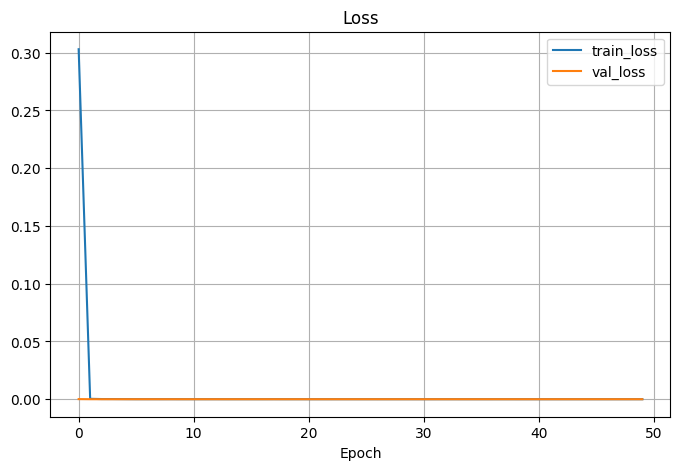

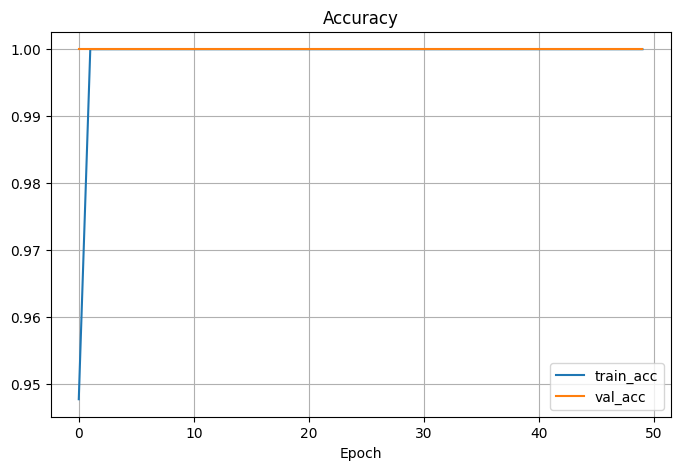

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_curve.png')
plt.show()


## Confusion Matrix & Classification Report (saved as image)

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


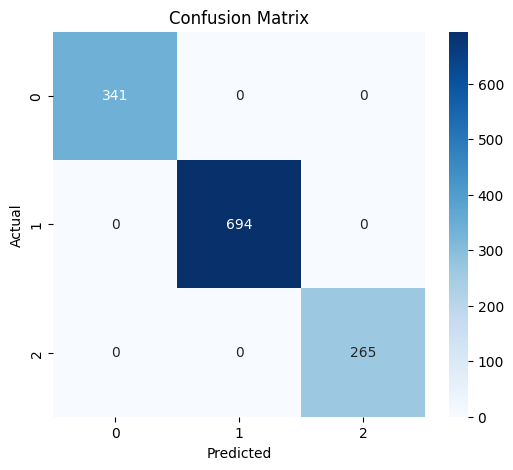


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       341
           1       1.00      1.00      1.00       694
           2       1.00      1.00      1.00       265

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



In [11]:
# Get predictions
if num_classes>2:
    y_pred = np.argmax(model.predict([Xg_test, Xc_test]), axis=1)
    y_true = np.argmax(y_test, axis=1)
else:
    y_prob = model.predict([Xg_test, Xc_test]).ravel()
    y_pred = (y_prob>0.5).astype(int)
    y_true = y_test

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

print('\nClassification Report:\n')
print(classification_report(y_true, y_pred))


## ROC Curve & AUC (binary only)

In [12]:
if num_classes==2:
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.savefig('roc_curve.png')
    plt.show()
else:
    print('ROC/AUC plot is available only for binary classification in this notebook')


ROC/AUC plot is available only for binary classification in this notebook


## Export to ONNX (requires tf2onnx)

In [13]:
# Convert to ONNX
!pip install -q tf2onnx onnx
import tf2onnx
import tensorflow as tf

loaded_model = tf.keras.models.load_model('pilot_multimodal_model.h5')
# Build input signature; use shapes with None for batch
spec = (tf.TensorSpec([None, SEQ_LEN, Xg.shape[2]], tf.float32, name='gaze_input'),
        tf.TensorSpec([None, SEQ_LEN, Xc.shape[2]], tf.float32, name='control_input'))
onnx_model, _ = tf2onnx.convert.from_keras(loaded_model, input_signature=spec, opset=13)
with open('pilot_model.onnx','wb') as f:
    f.write(onnx_model.SerializeToString())
print('Saved ONNX model to pilot_model.onnx')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.


ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x79af78a24d60>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x79af78a24d60>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x79af78a24d60>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x79af78a24d60>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x79af78a24d60>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x79af78a24d60>

Saved ONNX model to pilot_model.onnx


In [21]:
print("Gaze feature count:", len(gaze_cols), gaze_cols)
print("Control feature count:", len(control_cols), control_cols)

Gaze feature count: 4 ['gaze_x', 'gaze_y', 'fixation', 'yaw']
Control feature count: 4 ['pitch', 'roll', 'yaw', 'throttle']


## Export to TFLite

## Quick Prediction Example

In [15]:
idx = 0
sample_g = Xg_test[idx:idx+1]
sample_c = Xc_test[idx:idx+1]
pred = model.predict([sample_g, sample_c])
print('Raw model output:', pred)
if num_classes==2:
    print('Predicted class:', int(pred>0.5))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw model output: [[4.0875813e-11 1.0000000e+00 2.9957162e-11]]


In [17]:
import numpy as np
import pandas as pd

# Predictions for all test sequences
if len(y_test.shape) == 1:  # binary labels
    y_true = y_test
    y_prob = model.predict([Xg_test, Xc_test]).ravel()
    y_pred = (y_prob > 0.5).astype(int)
else:  # one-hot labels
    y_true = np.argmax(y_test, axis=1)
    y_prob_all = model.predict([Xg_test, Xc_test])
    y_prob = y_prob_all[:,1]  # probability of class 1
    y_pred = np.argmax(y_prob_all, axis=1)

# Build a table
prediction_table = pd.DataFrame({
    'Sample Index': np.arange(len(y_true)),
    'Actual Label': y_true,
    'Predicted Probability': y_prob,
    'Predicted Class': y_pred
})

# Round for readability
prediction_table['Predicted Probability'] = prediction_table['Predicted Probability'].round(4)

# Show first 20 rows
prediction_table.head(20)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


,Sample Index,Actual Label,Predicted Probability,Predicted Class
0,0,1,1.0,1
1,1,0,0.0,0
2,2,1,1.0,1
3,3,0,0.0,0
4,4,0,0.0,0
5,5,2,0.0,2
6,6,1,1.0,1
7,7,1,1.0,1
8,8,1,1.0,1
9,9,2,0.0,2


from matplotlib import pyplot as plt
_df_0['Sample Index'].plot(kind='hist', bins=20, title='Sample Index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Actual Label'].plot(kind='hist', bins=20, title='Actual Label')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Predicted Probability'].plot(kind='hist', bins=20, title='Predicted Probability')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Sample Index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Sample Index'}, axis=1)
              .sort_values('Sample Index', ascending=True))
  xs = counted['Sample Index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('Sample Index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Sample Index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_11['Sample Index'].plot(kind='line', figsize=(8, 4), title='Sample Index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_12['Actual Label'].plot(kind='line', figsize=(8, 4), title='Actual Label')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['Predicted Probability'].plot(kind='line', figsize=(8, 4), title='Predicted Probability')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['Predicted Class'].plot(kind='line', figsize=(8, 4), title='Predicted Class')
plt.gca().spines[['top', 'right']].set_visible(False)

In [18]:
import numpy as np
import pandas as pd

# === LABEL NAMES ===
label_map = {
    0: "Low Awareness",
    1: "Medium Awareness",
    2: "High Awareness"
}

# === PREDICT ALL TEST SAMPLES ===
y_prob_all = model.predict([Xg_test, Xc_test])
y_pred = np.argmax(y_prob_all, axis=1)
y_true = np.argmax(y_test, axis=1)

# === BUILD TABLE WITH LABEL NAMES ===
prediction_table = pd.DataFrame({
    "Sample Index": np.arange(len(y_true)),
    "Actual Label (ID)": y_true,
    "Actual Label (Name)": [label_map[i] for i in y_true],
    "Predicted Label (ID)": y_pred,
    "Predicted Label (Name)": [label_map[i] for i in y_pred],
    "Confidence (Highest Softmax)": y_prob_all.max(axis=1).round(4)
})

prediction_table.head(20)  # show first 20


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


,Sample Index,Actual Label (ID),Actual Label (Name),Predicted Label (ID),Predicted Label (Name),Confidence (Highest Softmax)
0,0,1,Medium Awareness,1,Medium Awareness,1.0
1,1,0,Low Awareness,0,Low Awareness,1.0
2,2,1,Medium Awareness,1,Medium Awareness,1.0
3,3,0,Low Awareness,0,Low Awareness,1.0
4,4,0,Low Awareness,0,Low Awareness,1.0
5,5,2,High Awareness,2,High Awareness,1.0
6,6,1,Medium Awareness,1,Medium Awareness,1.0
7,7,1,Medium Awareness,1,Medium Awareness,1.0
8,8,1,Medium Awareness,1,Medium Awareness,1.0
9,9,2,High Awareness,2,High Awareness,1.0


In [19]:
def highlight_match(row):
    color = "lightgreen" if row["Actual Label (ID)"] == row["Predicted Label (ID)"] else "salmon"
    return [f"background-color: {color}"] * len(row)

prediction_table.style.apply(highlight_match, axis=1)


,Sample Index,Actual Label (ID),Actual Label (Name),Predicted Label (ID),Predicted Label (Name),Confidence (Highest Softmax)
0,0,1,Medium Awareness,1,Medium Awareness,1.000000
1,1,0,Low Awareness,0,Low Awareness,1.000000
2,2,1,Medium Awareness,1,Medium Awareness,1.000000
3,3,0,Low Awareness,0,Low Awareness,1.000000
4,4,0,Low Awareness,0,Low Awareness,1.000000
5,5,2,High Awareness,2,High Awareness,1.000000
6,6,1,Medium Awareness,1,Medium Awareness,1.000000
7,7,1,Medium Awareness,1,Medium Awareness,1.000000
8,8,1,Medium Awareness,1,Medium Awareness,1.000000
9,9,2,High Awareness,2,High Awareness,1.000000


In [20]:
import joblib
import os

# Create model directory
os.makedirs("model", exist_ok=True)

# Save gaze scaler
joblib.dump(g_scaler, "model/g_scaler.pkl")

# Save control scaler
joblib.dump(c_scaler, "model/c_scaler.pkl")

print("Scalers saved successfully!")

Scalers saved successfully!


In [22]:
# ===============================
# INSTALL DEPENDENCIES
# ===============================
!pip install -q tensorflow scikit-learn pandas numpy

import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)

# ===============================
# LOAD YOUR FILES
# ===============================
DATA_PATH = "pilot_multimodal_dataset.csv"
MODEL_PATH = "pilot_multimodal_model.h5"
G_SCALER = "model/g_scaler.pkl"
C_SCALER = "model/c_scaler.pkl"

df = pd.read_csv(DATA_PATH)

model = tf.keras.models.load_model(MODEL_PATH)
g_scaler = joblib.load(G_SCALER)
c_scaler = joblib.load(C_SCALER)

# ===============================
# DETECT GAZE + CONTROL COLUMNS
# ===============================
gaze_cols = ['gaze_x','gaze_y','fixation','yaw']
control_cols = ['pitch','roll','yaw','throttle']

SEQ_LEN = 20
STEP = 5

# ===============================
# BUILD WINDOW SEQUENCES
# ===============================
def build_sequences(df):
    Xg, Xc, Y = [], [], []
    features = gaze_cols + control_cols
    arr = df[features].fillna(method='ffill').fillna(method='bfill').values
    labs = df['label'].values if 'label' in df.columns else np.zeros(len(df))

    for start in range(0, len(arr) - SEQ_LEN, STEP):
        seq = arr[start:start+SEQ_LEN]
        Xg.append(seq[:, :len(gaze_cols)])
        Xc.append(seq[:, len(gaze_cols):])
        Y.append(labs[start])

    return np.array(Xg), np.array(Xc), np.array(Y)

Xg, Xc, Y = build_sequences(df)

# ===============================
# APPLY SCALER
# ===============================
Xg = g_scaler.transform(Xg.reshape(-1, Xg.shape[2])).reshape(Xg.shape)
Xc = c_scaler.transform(Xc.reshape(-1, Xc.shape[2])).reshape(Xc.shape)

# ===============================
# SELECT 50 RANDOM SAMPLES
# ===============================
idxs = np.random.choice(len(Xg), 50, replace=False)
Xg_50 = Xg[idxs]
Xc_50 = Xc[idxs]

# ===============================
# PREDICT
# ===============================
pred_probs = model.predict([Xg_50, Xc_50])
pred_classes = np.argmax(pred_probs, axis=1)

label_map = {0:'Low Awareness',1:'Medium Awareness',2:'High Awareness'}

results = pd.DataFrame({
    "sample_id": idxs,
    "predicted_class": pred_classes,
    "predicted_label": [label_map[i] for i in pred_classes],
    "confidence": pred_probs.max(axis=1)
})

results.to_csv("real_50_predictions.csv", index=False)
results.head(10)


TensorFlow: 2.19.0


/tmp/ipython-input-1106920663.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  arr = df[features].fillna(method='ffill').fillna(method='bfill').values


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step


,sample_id,predicted_class,predicted_label,confidence
0,906,0,Low Awareness,1.0
1,2170,0,Low Awareness,1.0
2,6145,2,High Awareness,1.0
3,7213,1,Medium Awareness,1.0
4,1838,1,Medium Awareness,1.0
5,6374,2,High Awareness,1.0
6,2834,1,Medium Awareness,1.0
7,2910,1,Medium Awareness,1.0
8,4136,1,Medium Awareness,1.0
9,5477,1,Medium Awareness,1.0
